In [9]:
# =====================================================
# IMPORTS
# =====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import random

In [10]:
# =====================================================
# UPLOAD IMAGES
# =====================================================

from google.colab import files

uploaded = files.upload()

Saving img_2.jpeg to img_2 (1).jpeg
Saving img_1.jpeg to img_1 (1).jpeg


In [11]:
# =====================================================
# LOAD IMAGE
# =====================================================

import cv2

img1 = cv2.imread(
    "img_1.jpeg",
    cv2.IMREAD_GRAYSCALE
)

img2 = cv2.imread(
    "img_2.jpeg",
    cv2.IMREAD_GRAYSCALE
)

print(img1)
print(img2)

[[117 117 117 ... 228 228 228]
 [117 117 117 ... 228 228 228]
 [117 117 117 ... 228 228 228]
 ...
 [  6   6   6 ...  87  84  94]
 [  6   6   6 ... 101  93  92]
 [  6   6   6 ...  90  81  73]]
[[219 219 219 ... 255 255 255]
 [219 219 219 ... 255 255 255]
 [219 219 219 ... 255 255 255]
 ...
 [ 34  38  40 ...  48  45  46]
 [ 32  36  39 ...  45  46  52]
 [ 34  39  44 ...  43  48  56]]


In [12]:
# =====================================================
# GLOBAL PARAMETERS
# =====================================================

NUM_OCTAVES = 4

SIGMAS = [
    1.6,
    2.0,
    2.52,
    3.17,
    4.0,
    5.04,
    6.35,
    8.0
]

In [13]:
# =====================================================
# GAUSSIAN PYRAMID
# =====================================================
#
# Purpose:
# Create multiple blurred versions of the image
# at different scales.
#
# Output:
# pyramid[octave][scale]
#
# Example:
#
# Octave 0:
#   sigma = 1.6
#   sigma = 2.0
#   sigma = 2.52
#   ...
#
# Octave 1:
#   same sigmas but on half-sized image
#
# =====================================================

def build_gaussian_pyramid(
    img,
    num_octaves=NUM_OCTAVES,
    sigmas=SIGMAS
):

    # store all octaves
    pyramid = []

    # convert image to float
    current = img.astype(
        np.float32
    )

    # build each octave
    for octave in range(
        num_octaves
    ):

        octave_images = []

        # create blurred images
        for sigma in sigmas:

            blurred = cv2.GaussianBlur(
                current,
                (0, 0),
                sigma
            )

            octave_images.append(
                blurred
            )

        # save current octave
        pyramid.append(
            octave_images
        )

        # downsample image by factor 2
        current = cv2.resize(
            current,
            (
                current.shape[1] // 2,
                current.shape[0] // 2
            ),
            interpolation=cv2.INTER_AREA
        )

    return pyramid

In [14]:
# =====================================================
# TEST GAUSSIAN PYRAMID
# =====================================================

gauss_pyr = build_gaussian_pyramid(
    img1
)

print(
    "Number of Octaves:",
    len(gauss_pyr)
)

for i in range(
    len(gauss_pyr)
):
    print(
        f"Octave {i}:",
        gauss_pyr[i][0].shape
    )

Number of Octaves: 4
Octave 0: (1280, 720)
Octave 1: (640, 360)
Octave 2: (320, 180)
Octave 3: (160, 90)


In [15]:
# =====================================================
# DIFFERENCE OF GAUSSIAN PYRAMID
# =====================================================
#
# Purpose:
# Approximate the Laplacian of Gaussian.
#
# Output:
# dog_pyr[octave][dog_level]
#
# =====================================================

def build_dog_pyramid(
    gaussian_pyramid
):

    dog_pyramid = []

    for octave in gaussian_pyramid:

        dog_octave = []

        for i in range(
            len(octave) - 1
        ):

            dog = (
                octave[i + 1]
                -
                octave[i]
            )

            dog_octave.append(
                dog
            )

        dog_pyramid.append(
            dog_octave
        )

    return dog_pyramid

In [16]:
# =====================================================
# TEST DOG PYRAMID
# =====================================================

dog_pyr = build_dog_pyramid(
    gauss_pyr
)

print(
    "Number of Octaves:",
    len(dog_pyr)
)

for i in range(
    len(dog_pyr)
):
    print(
        f"Octave {i}:",
        len(dog_pyr[i])
    )

Number of Octaves: 4
Octave 0: 7
Octave 1: 7
Octave 2: 7
Octave 3: 7


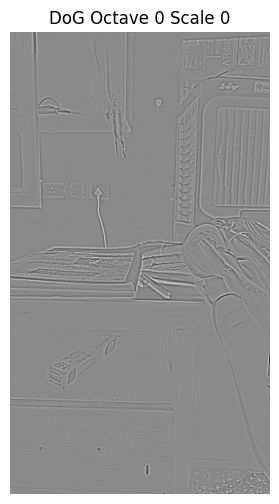

In [17]:
# visualise one dog image
plt.figure(figsize=(6,6))

plt.imshow(
    dog_pyr[0][0],
    cmap='gray'
)

plt.title(
    "DoG Octave 0 Scale 0"
)

plt.axis('off')

plt.show()

In [18]:
# =====================================================
# GRADIENT PYRAMID
# =====================================================
#
# Purpose:
# Compute gradient magnitude and orientation
# for every Gaussian image.
#
# Output:
#
# mag_pyr[octave][scale]
# ori_pyr[octave][scale]
#
# =====================================================

def build_gradient_pyramid(
    gaussian_pyramid
):

    mag_pyr = []

    ori_pyr = []

    for octave in gaussian_pyramid:

        octave_mag = []
        octave_ori = []

        for img in octave:

            # Sobel gradients
            dx = cv2.Sobel(
                img,
                cv2.CV_32F,
                1,
                0,
                ksize=3
            )

            dy = cv2.Sobel(
                img,
                cv2.CV_32F,
                0,
                1,
                ksize=3
            )

            # Gradient magnitude
            magnitude = np.sqrt(
                dx**2 + dy**2
            )

            # Gradient orientation
            orientation = (
                np.degrees(
                    np.arctan2(
                        dy,
                        dx
                    )
                )
                % 360
            )

            octave_mag.append(
                magnitude
            )

            octave_ori.append(
                orientation
            )

        mag_pyr.append(
            octave_mag
        )

        ori_pyr.append(
            octave_ori
        )

    return mag_pyr, ori_pyr

In [19]:
# =====================================================
# TEST GRADIENT PYRAMID
# =====================================================

mag_pyr, ori_pyr = build_gradient_pyramid(
    gauss_pyr
)

print(
    len(mag_pyr)
)

print(
    len(mag_pyr[0])
)

print(
    len(ori_pyr)
)

print(
    len(ori_pyr[0])
)

4
8
4
8


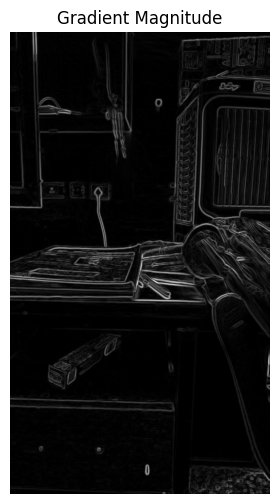

In [20]:
#visualise magnitude
plt.figure(figsize=(6,6))

plt.imshow(
    mag_pyr[0][0],
    cmap='gray'
)

plt.title(
    "Gradient Magnitude"
)

plt.axis("off")

plt.show()

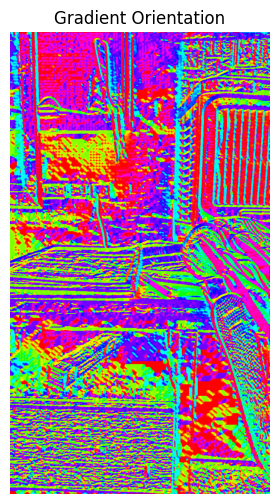

In [21]:
#visualise orientation
plt.figure(figsize=(6,6))

plt.imshow(
    ori_pyr[0][0],
    cmap='hsv'
)

plt.title(
    "Gradient Orientation"
)

plt.axis("off")

plt.show()

In [22]:
# =====================================================
# SCALE SPACE EXTREMA DETECTION
# =====================================================
#
# Purpose:
# Find maxima and minima in scale-space.
#
# Output:
#
# (x, y, octave, scale)
#
# =====================================================

def detect_extrema(
    dog_pyramid
):

    keypoints = []

    for octave_idx in range(
        len(dog_pyramid)
    ):

        octave = dog_pyramid[
            octave_idx
        ]

        # skip first and last scale
        for scale_idx in range(
            1,
            len(octave)-1
        ):

            prev_img = octave[
                scale_idx-1
            ]

            curr_img = octave[
                scale_idx
            ]

            next_img = octave[
                scale_idx+1
            ]

            h, w = curr_img.shape

            for y in range(
                1,
                h-1
            ):

                for x in range(
                    1,
                    w-1
                ):

                    value = curr_img[
                        y,
                        x
                    ]

                    neighbors = []

                    # previous scale
                    neighbors.extend(
                        prev_img[
                            y-1:y+2,
                            x-1:x+2
                        ].flatten()
                    )

                    # current scale
                    neighbors.extend(
                        curr_img[
                            y-1:y+2,
                            x-1:x+2
                        ].flatten()
                    )

                    # next scale
                    neighbors.extend(
                        next_img[
                            y-1:y+2,
                            x-1:x+2
                        ].flatten()
                    )

                    neighbors.remove(
                        value
                    )

                    if (
                        value > max(neighbors)
                        or
                        value < min(neighbors)
                    ):

                        keypoints.append(
                            (
                                x,
                                y,
                                octave_idx,
                                scale_idx
                            )
                        )

    return keypoints

In [23]:
# =====================================================
# TEST EXTREMA DETECTION
# =====================================================

extrema = detect_extrema(
    dog_pyr
)

print(
    "Extrema Found:",
    len(extrema)
)

Extrema Found: 6563


In [24]:
# =====================================================
# CONTRAST FILTER
# =====================================================
#
# Remove weak extrema.
#
# =====================================================

def contrast_filter(
    extrema,
    dog_pyramid,
    threshold=1.0
):

    filtered = []

    for x, y, octave, scale in extrema:

        value = abs(
            dog_pyramid[octave][scale][y, x]
        )

        if value > threshold:

            filtered.append(
                (
                    x,
                    y,
                    octave,
                    scale
                )
            )

    return filtered

In [25]:
contrast_pts = contrast_filter(
    extrema,
    dog_pyr
)

print(
    "After Contrast Filter:",
    len(contrast_pts)
)

After Contrast Filter: 3181


In [26]:
# =====================================================
# EDGE FILTER
# =====================================================
#
# Remove edge responses using Hessian matrix.
#
# =====================================================

def edge_filter(
    keypoints,
    dog_pyramid,
    r=10
):

    filtered = []

    for x, y, octave, scale in keypoints:

        img = dog_pyramid[octave][scale]

        if (
            x < 1
            or y < 1
            or x >= img.shape[1]-1
            or y >= img.shape[0]-1
        ):
            continue

        Dxx = (
            img[y, x+1]
            +
            img[y, x-1]
            -
            2 * img[y, x]
        )

        Dyy = (
            img[y+1, x]
            +
            img[y-1, x]
            -
            2 * img[y, x]
        )

        Dxy = (
            img[y+1, x+1]
            -
            img[y+1, x-1]
            -
            img[y-1, x+1]
            +
            img[y-1, x-1]
        ) / 4.0

        trace = Dxx + Dyy

        det = (
            Dxx * Dyy
            -
            Dxy * Dxy
        )

        if det <= 0:
            continue

        ratio = (
            trace * trace
        ) / det

        threshold = (
            (r + 1) ** 2
        ) / r

        if ratio < threshold:

            filtered.append(
                (
                    x,
                    y,
                    octave,
                    scale
                )
            )

    return filtered

In [27]:
edge_pts = edge_filter(
    contrast_pts,
    dog_pyr
)

print(
    "After Edge Filter:",
    len(edge_pts)
)

After Edge Filter: 1659


In [28]:
# =====================================================
# NON MAXIMUM SUPPRESSION
# =====================================================

def nms_filter(
    keypoints,
    dog_pyramid,
    radius=5
):

    scored = []

    for x, y, octave, scale in keypoints:

        response = abs(
            dog_pyramid[octave][scale][y, x]
        )

        scored.append(
            (
                response,
                x,
                y,
                octave,
                scale
            )
        )

    scored.sort(
        reverse=True
    )

    selected = []

    for response, x, y, octave, scale in scored:

        keep = True

        for _, sx, sy, so, ss in selected:

            if octave != so:
                continue

            dist = np.sqrt(
                (x - sx)**2
                +
                (y - sy)**2
            )

            if dist < radius:

                keep = False
                break

        if keep:

            selected.append(
                (
                    response,
                    x,
                    y,
                    octave,
                    scale
                )
            )

    result = []

    for _, x, y, octave, scale in selected:

        result.append(
            (
                x,
                y,
                octave,
                scale
            )
        )

    return result

In [29]:
nms_pts = nms_filter(
    edge_pts,
    dog_pyr,
    radius=10
)

print(
    "After NMS:",
    len(nms_pts)
)

After NMS: 1063


In [30]:
# =====================================================
# MULTI ORIENTATION ASSIGNMENT
# =====================================================
#
# Input:
# (x,y,octave,scale)
#
# Output:
# (x,y,octave,scale,orientation)
#
# =====================================================

def assign_orientations_multi(
    keypoints,
    mag_pyr,
    ori_pyr,
    sigmas=SIGMAS
):

    oriented_keypoints = []

    for x, y, octave, scale in keypoints:

        magnitude = mag_pyr[octave][scale]
        orientation = ori_pyr[octave][scale]

        # sigma corresponding to this scale
        sigma = sigmas[scale]

        # radius used by Lowe
        radius = int(round(3 * 1.5 * sigma))

        hist = np.zeros(36)

        h, w = magnitude.shape

        for dy in range(-radius, radius + 1):

            for dx in range(-radius, radius + 1):

                yy = y + dy
                xx = x + dx

                if (
                    yy < 0
                    or yy >= h
                    or xx < 0
                    or xx >= w
                ):
                    continue

                # Gaussian weighting
                weight = np.exp(
                    -(dx*dx + dy*dy)
                    /
                    (2 * (1.5*sigma)**2)
                )

                mag = magnitude[yy, xx]

                ang = orientation[yy, xx]

                bin_idx = int(
                    np.floor(ang / 10)
                ) % 36

                hist[bin_idx] += (
                    weight * mag
                )

        max_peak = np.max(hist)

        # create orientation(s)
        for bin_idx in range(36):

            if hist[bin_idx] >= 0.8 * max_peak:

                angle = (
                    bin_idx + 0.5
                ) * 10

                oriented_keypoints.append(
                    (
                        x,
                        y,
                        octave,
                        scale,
                        angle
                    )
                )

    return oriented_keypoints

In [31]:
oriented_kps = assign_orientations_multi(
    nms_pts,
    mag_pyr,
    ori_pyr
)

print(
    "Keypoints Before Orientation:",
    len(nms_pts)
)

print(
    "Keypoints After Orientation:",
    len(oriented_kps)
)

Keypoints Before Orientation: 1063
Keypoints After Orientation: 1496


In [32]:
print(len(nms_pts))
print(len(oriented_kps))

1063
1496


In [33]:
# =====================================================
# TRILINEAR SIFT DESCRIPTOR
# =====================================================
#
# Output:
# 128 dimensional descriptor
#
# 4 x 4 spatial cells
# 8 orientation bins
#
# =====================================================

def generate_descriptors(
    oriented_keypoints,
    mag_pyr,
    ori_pyr
):

    descriptors = []
    valid_keypoints = []

    for x, y, octave, scale, kp_angle in oriented_keypoints:

        mag = mag_pyr[octave][scale]
        ori = ori_pyr[octave][scale]

        h, w = mag.shape

        descriptor = np.zeros(
            (4,4,8),
            dtype=np.float32
        )

        # 16x16 descriptor window
        radius = 8

        angle_rad = np.deg2rad(
            kp_angle
        )

        cos_t = np.cos(
            angle_rad
        )

        sin_t = np.sin(
            angle_rad
        )

        for dy in range(
            -radius,
            radius
        ):

            for dx in range(
                -radius,
                radius
            ):

                yy = y + dy
                xx = x + dx

                if (
                    yy < 0
                    or yy >= h
                    or xx < 0
                    or xx >= w
                ):
                    continue

                # ----------------------------------
                # Rotate coordinates into keypoint frame
                # ----------------------------------

                x_rot = (
                    cos_t * dx
                    +
                    sin_t * dy
                )

                y_rot = (
                    -sin_t * dx
                    +
                    cos_t * dy
                )

                # ----------------------------------
                # Convert to descriptor coordinates
                # ----------------------------------

                col_bin = (
                    x_rot / 4.0
                ) + 1.5

                row_bin = (
                    y_rot / 4.0
                ) + 1.5

                if (
                    row_bin < 0
                    or row_bin >= 4
                    or col_bin < 0
                    or col_bin >= 4
                ):
                    continue

                # ----------------------------------
                # Relative orientation
                # ----------------------------------

                angle = (
                    ori[yy,xx]
                    -
                    kp_angle
                ) % 360

                ori_bin = (
                    angle / 45.0
                )

                sigma_desc = 8.0

                gaussian_weight = np.exp(
                    -(x_rot*x_rot + y_rot*y_rot)
                    /
                    (2 * sigma_desc * sigma_desc)
                )

                magnitude = (
                    mag[yy, xx]
                    *
                    gaussian_weight
                )

                # ----------------------------------
                # Row interpolation
                # ----------------------------------

                r0 = int(
                    np.floor(row_bin)
                )

                r1 = r0 + 1

                wr1 = (
                    row_bin - r0
                )

                wr0 = (
                    1 - wr1
                )

                # ----------------------------------
                # Column interpolation
                # ----------------------------------

                c0 = int(
                    np.floor(col_bin)
                )

                c1 = c0 + 1

                wc1 = (
                    col_bin - c0
                )

                wc0 = (
                    1 - wc1
                )

                # ----------------------------------
                # Orientation interpolation
                # ----------------------------------

                o0 = int(
                    np.floor(ori_bin)
                ) % 8

                o1 = (
                    o0 + 1
                ) % 8

                wo1 = (
                    ori_bin
                    -
                    np.floor(
                        ori_bin
                    )
                )

                wo0 = (
                    1 - wo1
                )

                # ----------------------------------
                # Trilinear interpolation
                # ----------------------------------

                for r, wr in [
                    (r0,wr0),
                    (r1,wr1)
                ]:

                    if not (
                        0 <= r < 4
                    ):
                        continue

                    for c, wc in [
                        (c0,wc0),
                        (c1,wc1)
                    ]:

                        if not (
                            0 <= c < 4
                        ):
                            continue

                        descriptor[
                            r,
                            c,
                            o0
                        ] += (
                            magnitude
                            *
                            wr
                            *
                            wc
                            *
                            wo0
                        )

                        descriptor[
                            r,
                            c,
                            o1
                        ] += (
                            magnitude
                            *
                            wr
                            *
                            wc
                            *
                            wo1
                        )

        # ----------------------------------
        # Flatten
        # ----------------------------------

        descriptor = descriptor.flatten()

        # ----------------------------------
        # Normalize
        # ----------------------------------

        norm = np.linalg.norm(
            descriptor
        )

        if norm > 1e-7:

            descriptor /= norm

            descriptor = np.clip(
                descriptor,
                0,
                0.2
            )

            descriptor /= (
                np.linalg.norm(
                    descriptor
                )
                +
                1e-7
            )

        descriptors.append(
            descriptor
        )

        valid_keypoints.append(
            (
                x,
                y,
                octave,
                scale,
                kp_angle
            )
        )

    return (
        valid_keypoints,
        np.array(descriptors)
    )

In [34]:
kp1_desc, desc1 = generate_descriptors(
    oriented_kps,
    mag_pyr,
    ori_pyr
)

print(
    len(kp1_desc)
)

print(
    desc1.shape
)

1496
(1496, 128)


In [35]:
print(len(kp1_desc))
print(len(desc1))
print(desc1.shape)

1496
1496
(1496, 128)


Image

↓

Gaussian Pyramid

↓

DoG Pyramid

↓

Extrema Detection

↓

Contrast Filter

↓

Edge Filter

↓

NMS

↓

Multi-Orientation Assignment

↓

Trilinear Descriptor


Extrema             : 6563,
After Contrast      : 3181,
After Edge          : 1659,
After NMS           : 738,
After Orientation   : 1057,
Descriptors         : (1057,128),

In [36]:
# =====================================================
# COMPLETE SIFT PIPELINE
# =====================================================

def run_sift_pipeline(
    img
):

    gauss = build_gaussian_pyramid(img)

    dog = build_dog_pyramid(gauss)

    mag, ori = build_gradient_pyramid(
        gauss
    )

    extrema = detect_extrema(dog)

    contrast = contrast_filter(
        extrema,
        dog,
        threshold=1.0
    )

    edge = edge_filter(
        contrast,
        dog
    )

    nms = nms_filter(
        edge,
        dog,
        radius=10
    )

    oriented = assign_orientations_multi(
        nms,
        mag,
        ori
    )

    kp, desc = generate_descriptors(
        oriented,
        mag,
        ori
    )

    return kp, desc

In [37]:
kp1, desc1 = run_sift_pipeline(
    img1
)

kp2, desc2 = run_sift_pipeline(
    img2
)

print(
    len(kp1),
    len(kp2)
)

print(
    desc1.shape,
    desc2.shape
)

1496 2183
(1496, 128) (2183, 128)


In [38]:
# =====================================================
# DESCRIPTOR MATCHING
# =====================================================
#
# Lowe Ratio Test
#
# =====================================================

def match_descriptors(
    desc1,
    desc2,
    ratio=0.75
):

    matches = []

    for i in range(len(desc1)):

        d1 = desc1[i]

        distances = np.linalg.norm(
            desc2 - d1,
            axis=1
        )

        if len(distances) < 2:
            continue

        idx = np.argsort(
            distances
        )

        best = idx[0]
        second = idx[1]

        if (
            distances[best]
            <
            ratio * distances[second]
        ):

            matches.append(
                (
                    i,
                    best,
                    distances[best]
                )
            )

    return matches

In [39]:
matches = match_descriptors(
    desc1,
    desc2
)

print(
    "Matches:",
    len(matches)
)

Matches: 222


In [40]:
# =====================================================
# REPROJECTION ERROR
# =====================================================

def reprojection_error(
    H,
    src_pt,
    dst_pt
):

    p = np.array([
        src_pt[0],
        src_pt[1],
        1.0
    ])

    projected = H @ p

    if abs(projected[2]) < 1e-10:
        return np.inf

    projected /= projected[2]

    error = np.linalg.norm(
        projected[:2]
        -
        dst_pt
    )

    return error

In [56]:
kp1, desc1 = run_sift_pipeline(img1)

kp2, desc2 = run_sift_pipeline(img2)

matches = match_descriptors(
    desc1,
    desc2
)

print(len(kp1))
print(len(kp2))
print(len(matches))

1496
2183
222


RANSAC AND HOMOGRAPHY MATRIX CALCULATION PART


In [57]:
import numpy as np

def compute_homography_dlt(
    src_pts,
    dst_pts
):

    A = []

    for (x,y),(u,v) in zip(
        src_pts,
        dst_pts
    ):

        A.append([
            -x,-y,-1,
             0,0,0,
             x*u,y*u,u
        ])

        A.append([
             0,0,0,
            -x,-y,-1,
             x*v,y*v,v
        ])

    A = np.array(
        A,
        dtype=np.float64
    )

    _,_,Vt = np.linalg.svd(A)

    H = Vt[-1].reshape(3,3)

    H /= H[2,2]

    return H

In [58]:
def reprojection_error(
    H,
    src_pt,
    dst_pt
):

    p = np.array([
        src_pt[0],
        src_pt[1],
        1.0
    ])

    projected = H @ p

    projected /= projected[2]

    return np.linalg.norm(
        projected[:2]
        -
        dst_pt
    )

In [59]:
import random

def custom_ransac_filter(
    kp1,
    kp2,
    matches,
    iterations=2000,
    threshold=5
):

    best_H = None

    best_inliers = []

    if len(matches) < 4:

        return [], None

    for _ in range(iterations):

        sample = random.sample(
            matches,
            4
        )

        src_pts = np.array([
            kp1[i][:2]
            for i,j,d in sample
        ])

        dst_pts = np.array([
            kp2[j][:2]
            for i,j,d in sample
        ])

        try:

            H = compute_homography_dlt(
                src_pts,
                dst_pts
            )

        except:

            continue

        current_inliers = []

        for i,j,d in matches:

            src = np.array(
                kp1[i][:2]
            )

            dst = np.array(
                kp2[j][:2]
            )

            error = reprojection_error(
                H,
                src,
                dst
            )

            if error < threshold:

                current_inliers.append(
                    (i,j,d)
                )

        if len(current_inliers) > len(best_inliers):

            best_inliers = current_inliers

            best_H = H

    return (
        best_inliers,
        best_H
    )

In [60]:
inliers, H = custom_ransac_filter(
    kp1,
    kp2,
    matches,
    iterations=2000,
    threshold=5
)

print("Matches :", len(matches))
print("Inliers :", len(inliers))

print("\nHomography:\n")
print(H)

Matches : 222
Inliers : 102

Homography:

[[ 1.20732845e+00  4.54516451e-02 -3.35915196e+02]
 [ 1.45836782e-01  1.11857477e+00 -3.97921325e+01]
 [ 3.12869099e-04 -2.28241743e-05  1.00000000e+00]]


In [61]:
def refine_homography(
    kp1,
    kp2,
    inliers
):

    src_pts = np.array([
        kp1[i][:2]
        for i,j,d in inliers
    ])

    dst_pts = np.array([
        kp2[j][:2]
        for i,j,d in inliers
    ])

    H_final = compute_homography_dlt(
        src_pts,
        dst_pts
    )

    return H_final

In [62]:
H_final = refine_homography(
    kp1,
    kp2,
    inliers
)

print(H_final)

[[ 1.21684538e+00  4.08700048e-02 -3.36651092e+02]
 [ 1.59039405e-01  1.10980384e+00 -4.12875057e+01]
 [ 3.32374799e-04 -3.47049051e-05  1.00000000e+00]]


In [63]:
def average_reprojection_error(
    H,
    kp1,
    kp2,
    inliers
):

    errors = []

    for i,j,d in inliers:

        src = np.array(
            kp1[i][:2]
        )

        dst = np.array(
            kp2[j][:2]
        )

        errors.append(

            reprojection_error(
                H,
                src,
                dst
            )

        )

    return np.mean(errors)

In [64]:
avg_error = average_reprojection_error(
    H_final,
    kp1,
    kp2,
    inliers
)

print(
    "Average Reprojection Error:",
    avg_error
)

Average Reprojection Error: 1.2286940614456754


In [65]:

print(H_final)

[[ 1.21684538e+00  4.08700048e-02 -3.36651092e+02]
 [ 1.59039405e-01  1.10980384e+00 -4.12875057e+01]
 [ 3.32374799e-04 -3.47049051e-05  1.00000000e+00]]


In [66]:

avg_error

np.float64(1.2286940614456754)

In [67]:
len(inliers)

102

In [68]:
def symmetric_reprojection_error(
    H,
    src_pt,
    dst_pt
):

    H_inv = np.linalg.inv(H)

    # --------------------
    # Forward
    # --------------------

    p1 = np.array([
        src_pt[0],
        src_pt[1],
        1.0
    ])

    pred2 = H @ p1

    pred2 /= pred2[2]

    ef = np.linalg.norm(
        pred2[:2]
        -
        dst_pt
    )

    # --------------------
    # Backward
    # --------------------

    p2 = np.array([
        dst_pt[0],
        dst_pt[1],
        1.0
    ])

    pred1 = H_inv @ p2

    pred1 /= pred1[2]

    eb = np.linalg.norm(
        pred1[:2]
        -
        src_pt
    )

    # --------------------
    # Combined Error
    # --------------------

    return np.sqrt(
        ef**2
        +
        eb**2
    )

In [69]:
def average_symmetric_error(
    H,
    kp1,
    kp2,
    inliers
):

    errors = []

    for i,j,d in inliers:

        src = np.array(
            kp1[i][:2]
        )

        dst = np.array(
            kp2[j][:2]
        )

        errors.append(

            symmetric_reprojection_error(
                H,
                src,
                dst
            )

        )

    return np.mean(errors)

In [70]:
avg_sym_error = average_symmetric_error(
    H_final,
    kp1,
    kp2,
    inliers
)

print(
    "Average Symmetric Error:",
    avg_sym_error
)

Average Symmetric Error: 1.740409643537789


In [71]:
errors = []

for i,j,d in inliers:

    src = np.array(
        kp1[i][:2]
    )

    dst = np.array(
        kp2[j][:2]
    )

    errors.append(

        symmetric_reprojection_error(
            H_final,
            src,
            dst
        )

    )

print(
    "Min Error :",
    np.min(errors)
)

print(
    "Mean Error :",
    np.mean(errors)
)

print(
    "Median Error :",
    np.median(errors)
)

print(
    "Max Error :",
    np.max(errors)
)

Min Error : 0.19114136974980792
Mean Error : 1.740409643537789
Median Error : 1.5616803302239943
Max Error : 4.14688073748106


In [72]:
print(avg_sym_error)
print(np.max(errors))

1.740409643537789
4.14688073748106


In [73]:
H_inv = np.linalg.inv(
    H_final
)

print(H_inv)

[[ 7.55178411e-01 -1.98859960e-02  2.53410594e+02]
 [-1.17710034e-01  9.05324651e-01 -2.24861471e+00]
 [-2.55087388e-04  3.80288100e-05  9.15694667e-01]]


In [74]:
def inverse_warp(
    src_img,
    H_inv,
    output_shape
):

    h_out, w_out = output_shape

    warped = np.zeros(
        (
            h_out,
            w_out,
            3
        ),
        dtype=np.uint8
    )

    for y_dst in range(h_out):

        for x_dst in range(w_out):

            p_dst = np.array([
                x_dst,
                y_dst,
                1.0
            ])

            p_src = H_inv @ p_dst

            p_src /= p_src[2]

            x_src = p_src[0]
            y_src = p_src[1]

            x_src = int(
                round(x_src)
            )

            y_src = int(
                round(y_src)
            )

            if (
                0 <= x_src < src_img.shape[1]
                and
                0 <= y_src < src_img.shape[0]
            ):

                warped[
                    y_dst,
                    x_dst
                ] = src_img[
                    y_src,
                    x_src
                ]

    return warped

In [75]:
warped_img1 = inverse_warp(
    img1,
    H_inv,
    (
        img2.shape[0],
        img2.shape[1]
    )
)

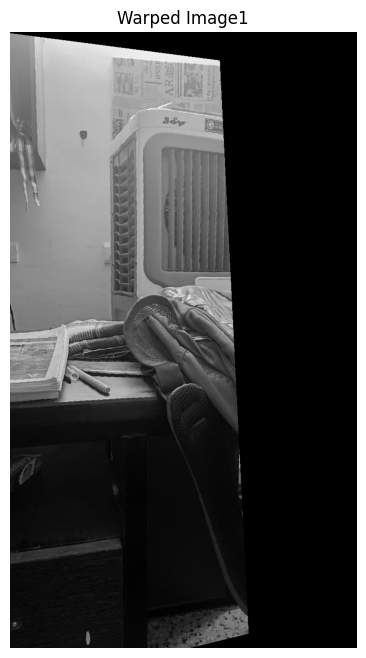

In [76]:
plt.figure(
    figsize=(15,8)
)

plt.imshow(
    cv2.cvtColor(
        warped_img1,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    "Warped Image1"
)

plt.show()

In [80]:
print("warped_img1:", warped_img1.shape)
print("img2:", img2.shape)

warped_img1: (1280, 720, 3)
img2: (1280, 720)


In [81]:
img2_color = cv2.cvtColor(
    img2,
    cv2.COLOR_GRAY2BGR
)

In [82]:
print(warped_img1.shape)
print(img2_color.shape)

(1280, 720, 3)
(1280, 720, 3)


In [83]:
overlay = cv2.addWeighted(
    warped_img1,
    0.5,
    img2_color,
    0.5,
    0
)

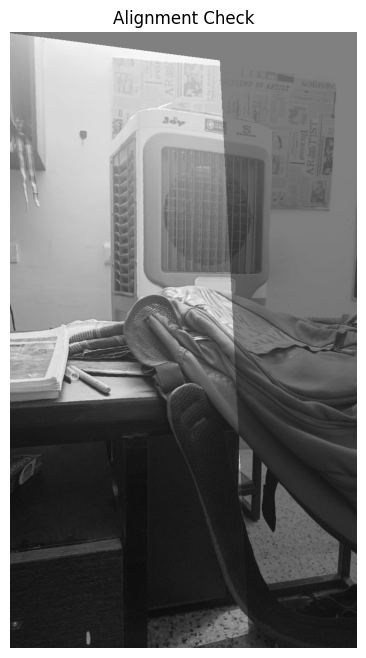

In [84]:
plt.figure(
    figsize=(12,8)
)

plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    "Alignment Check"
)

plt.show()

In [85]:
corners = np.array([
    [0,0],
    [img1.shape[1],0],
    [img1.shape[1],img1.shape[0]],
    [0,img1.shape[0]]
], dtype=np.float32)

In [86]:
corners_h = np.hstack([
    corners,
    np.ones((4,1))
])

In [87]:
mapped = (H_final @ corners_h.T).T

In [88]:
mapped = mapped / mapped[:,2:3]

In [89]:
mapped_xy = mapped[:,:2]

print(mapped_xy)

[[-336.65109212  -41.28750572]
 [ 435.30484309   59.08196846]
 [ 495.26934563 1250.13416053]
 [-297.55558297 1443.37961772]]


In [90]:
img2_vis = cv2.cvtColor(
    img2,
    cv2.COLOR_GRAY2BGR
)

In [91]:
pts = mapped_xy.astype(np.int32)

cv2.polylines(
    img2_vis,
    [pts],
    True,
    (0,255,0),
    3
)

array([[[  0, 255,   0],
        [219, 219, 219],
        [219, 219, 219],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 34,  34,  34],
        [ 38,  38,  38],
        [ 40,  40,  40],
        ...,
        [ 48,  48,  48],
        [ 45,  45,  45],
        [ 46,  46,  46]],

       [[ 32,  32,  32],
        [ 36,  36,  36],
        [ 39,  39,  39],
        ...,
        [ 45,  45,  45],
        [ 46,  46,  46],
        [ 52,  52,  52]],

       [[ 34,  34,  34],
        [ 39,  39,  39],
        [ 44,  44,  44],
        ...,
        [ 43,  43,  43],
        [ 48,  48,  48],
        [ 56,  56,  56]]

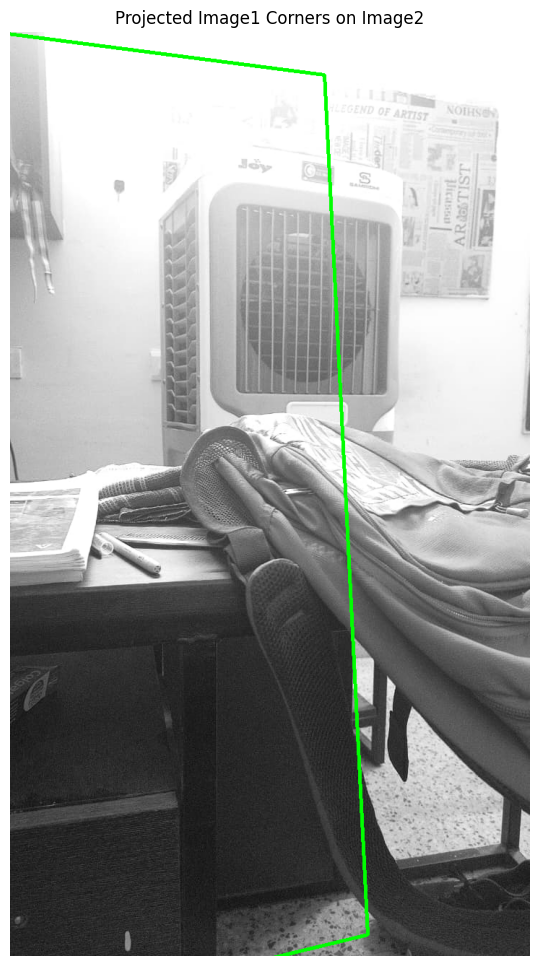

In [92]:
plt.figure(figsize=(8,12))

plt.imshow(
    cv2.cvtColor(
        img2_vis,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title("Projected Image1 Corners on Image2")
plt.show()

USING BILINEAR INTERPOLATION FOR BETTER WARPING

In [93]:
def bilinear_sample(
    img,
    x,
    y
):

    h, w = img.shape[:2]

    if (
        x < 0
        or x >= w - 1
        or y < 0
        or y >= h - 1
    ):
        return np.zeros(
            3,
            dtype=np.uint8
        )

    x0 = int(np.floor(x))
    x1 = x0 + 1

    y0 = int(np.floor(y))
    y1 = y0 + 1

    dx = x - x0
    dy = y - y0

    I00 = img[y0, x0].astype(np.float32)
    I10 = img[y0, x1].astype(np.float32)
    I01 = img[y1, x0].astype(np.float32)
    I11 = img[y1, x1].astype(np.float32)

    top = (
        (1 - dx) * I00
        +
        dx * I10
    )

    bottom = (
        (1 - dx) * I01
        +
        dx * I11
    )

    value = (
        (1 - dy) * top
        +
        dy * bottom
    )

    return value.astype(np.uint8)

In [96]:
def inverse_warp_bilinear(
    src_img,
    H_inv,
    output_shape
):

    h_out, w_out = output_shape

    warped = np.zeros(
        (
            h_out,
            w_out,
            3
        ),
        dtype=np.uint8
    )

    for y_dst in range(h_out):

        for x_dst in range(w_out):

            p_dst = np.array([
                x_dst,
                y_dst,
                1.0
            ])

            p_src = H_inv @ p_dst

            p_src /= p_src[2]

            x_src = p_src[0]
            y_src = p_src[1]

            warped[
                y_dst,
                x_dst
            ] = bilinear_sample(
                src_img,
                x_src,
                y_src
            )

    return warped

In [98]:
print(img1.shape)
print(img2.shape)

(1280, 720)
(1280, 720)


In [99]:
img1_color = cv2.cvtColor(
    img1,
    cv2.COLOR_GRAY2BGR
)

img2_color = cv2.cvtColor(
    img2,
    cv2.COLOR_GRAY2BGR
)

In [101]:
print(img1_color.shape)
print(img2_color.shape)

(1280, 720, 3)
(1280, 720, 3)


In [102]:
warped_img1 = inverse_warp_bilinear(
    img1_color,
    H_inv,
    (
        img2.shape[0],
        img2.shape[1]
    )
)


In [103]:
overlay = cv2.addWeighted(
    warped_img1,
    0.5,
    img2_color,
    0.5,
    0
)

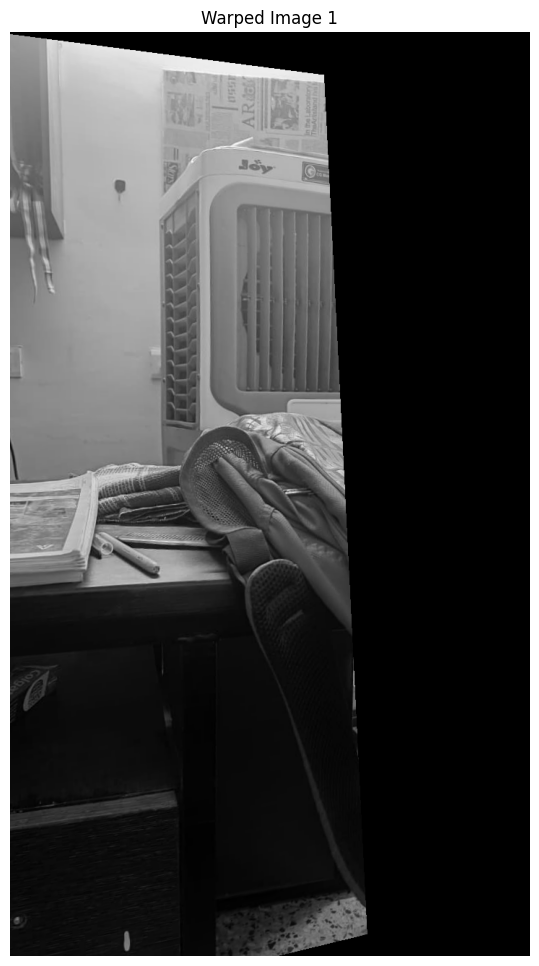

In [104]:
plt.figure(figsize=(8,12))

plt.imshow(
    cv2.cvtColor(
        warped_img1,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Warped Image 1")
plt.axis("off")

plt.show()

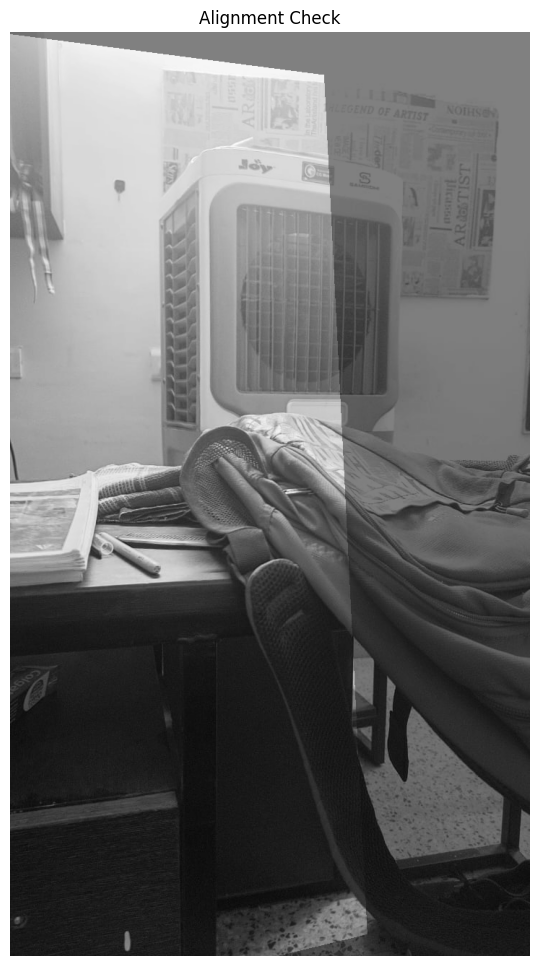

In [105]:
plt.figure(figsize=(8,12))

plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Alignment Check")
plt.axis("off")

plt.show()

CREATING THE CANVAS AND FURTHER BLENDING PROCESS


In [110]:
def get_transformed_corners(
    img,
    H
):

    h, w = img.shape[:2]

    corners = np.array([
        [0,0],
        [w,0],
        [w,h],
        [0,h]
    ], dtype=np.float32)

    corners_h = np.hstack([
        corners,
        np.ones((4,1))
    ])

    transformed = (
        H @ corners_h.T
    ).T

    transformed /= transformed[:,2:3]

    return transformed[:,:2]

In [111]:
corners1 = get_transformed_corners(
    img1,
    H_final
)

print(corners1)

[[-336.65109212  -41.28750572]
 [ 435.30484309   59.08196846]
 [ 495.26934563 1250.13416053]
 [-297.55558297 1443.37961772]]


In [112]:
h2, w2 = img2.shape[:2]

corners2 = np.array([
    [0,0],
    [w2,0],
    [w2,h2],
    [0,h2]
], dtype=np.float32)

all_corners = np.vstack([
    corners1,
    corners2
])

xmin = int(np.floor(np.min(all_corners[:,0])))
ymin = int(np.floor(np.min(all_corners[:,1])))

xmax = int(np.ceil(np.max(all_corners[:,0])))
ymax = int(np.ceil(np.max(all_corners[:,1])))

print(
    "xmin =", xmin,
    "ymin =", ymin,
    "xmax =", xmax,
    "ymax =", ymax
)

xmin = -337 ymin = -42 xmax = 720 ymax = 1444


In [113]:
offset_x = -xmin
offset_y = -ymin

print(offset_x)
print(offset_y)

T = np.array([
    [1,0,offset_x],
    [0,1,offset_y],
    [0,0,1]
])

337
42


In [114]:
H_panorama = T @ H_final

print(H_panorama)

[[ 1.32885569e+00  2.91744518e-02  3.48907883e-01]
 [ 1.72999146e-01  1.10834623e+00  7.12494278e-01]
 [ 3.32374799e-04 -3.47049051e-05  1.00000000e+00]]


In [116]:
# =====================================================
# FIND PANORAMA BOUNDARIES
#
# Purpose:
# Find the minimum canvas size needed
# to contain both Image1 (warped)
# and Image2 (original).
# =====================================================

h2, w2 = img2.shape[:2]

corners2 = np.array([
    [0,0],
    [w2,0],
    [w2,h2],
    [0,h2]
], dtype=np.float32)

# Combine corners of both images

all_corners = np.vstack([
    corners1,
    corners2
])

# Find bounding box

xmin = int(
    np.floor(
        np.min(all_corners[:,0])
    )
)

ymin = int(
    np.floor(
        np.min(all_corners[:,1])
    )
)

xmax = int(
    np.ceil(
        np.max(all_corners[:,0])
    )
)

ymax = int(
    np.ceil(
        np.max(all_corners[:,1])
    )
)

print("xmin =", xmin)
print("ymin =", ymin)
print("xmax =", xmax)
print("ymax =", ymax)

xmin = -337
ymin = -42
xmax = 720
ymax = 1444


In [117]:
# =====================================================
# COMPUTE CANVAS OFFSETS
#
# Purpose:
# Shift all coordinates so that
# the panorama starts from (0,0)
# instead of negative coordinates.
# =====================================================

offset_x = -xmin
offset_y = -ymin

print("offset_x =", offset_x)
print("offset_y =", offset_y)

offset_x = 337
offset_y = 42


In [118]:
# =====================================================
# CREATE PANORAMA HOMOGRAPHY
#
# Purpose:
# Move warped image into positive
# panorama coordinates.
# =====================================================

T = np.array([
    [1,0,offset_x],
    [0,1,offset_y],
    [0,0,1]
])

H_panorama = T @ H_final

print(H_panorama)

[[ 1.32885569e+00  2.91744518e-02  3.48907883e-01]
 [ 1.72999146e-01  1.10834623e+00  7.12494278e-01]
 [ 3.32374799e-04 -3.47049051e-05  1.00000000e+00]]


In [119]:
# =====================================================
# COMPUTE FINAL CANVAS SIZE
#
# Purpose:
# Determine panorama width and height.
# =====================================================

canvas_width = xmax - xmin
canvas_height = ymax - ymin

print(
    "Canvas Width =",
    canvas_width
)

print(
    "Canvas Height =",
    canvas_height
)

Canvas Width = 1057
Canvas Height = 1486


In [120]:
print(canvas_width)
print(canvas_height)

print(offset_x)
print(offset_y)

1057
1486
337
42


In [121]:
# =====================================================
# CREATE PANORAMA CANVAS
#
# Purpose:
# Create a blank image large enough
# to contain both images.
# =====================================================

canvas = np.zeros(
    (
        canvas_height,
        canvas_width,
        3
    ),
    dtype=np.uint8
)

print(canvas.shape)

(1486, 1057, 3)


In [122]:
# =====================================================
# PLACE IMAGE2 INTO PANORAMA COORDINATES
#
# Purpose:
# Move Image2 into the panorama canvas.
# =====================================================

img2_canvas = np.zeros_like(
    canvas
)

img2_canvas[
    offset_y:offset_y+h2,
    offset_x:offset_x+w2
] = img2_color

print(img2_canvas.shape)

(1486, 1057, 3)


In [123]:
# =====================================================
# WARP IMAGE1 INTO PANORAMA COORDINATES
#
# Purpose:
# Use panorama homography so Image1
# lands in the correct location inside
# the panorama canvas.
# =====================================================

H_panorama_inv = np.linalg.inv(
    H_panorama
)

warped_img1 = inverse_warp_bilinear(
    img1_color,
    H_panorama_inv,
    (
        canvas_height,
        canvas_width
    )
)

print(warped_img1.shape)

(1486, 1057, 3)


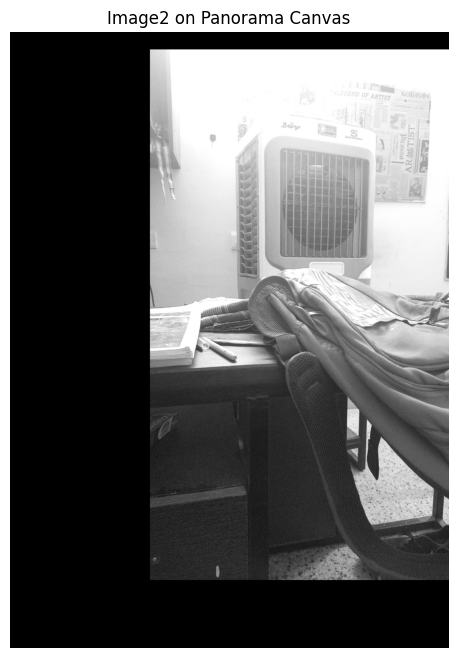

In [124]:
# =====================================================
# VISUALIZE IMAGE2 INSIDE PANORAMA
# =====================================================

plt.figure(figsize=(10,8))

plt.imshow(
    cv2.cvtColor(
        img2_canvas,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title("Image2 on Panorama Canvas")

plt.show()

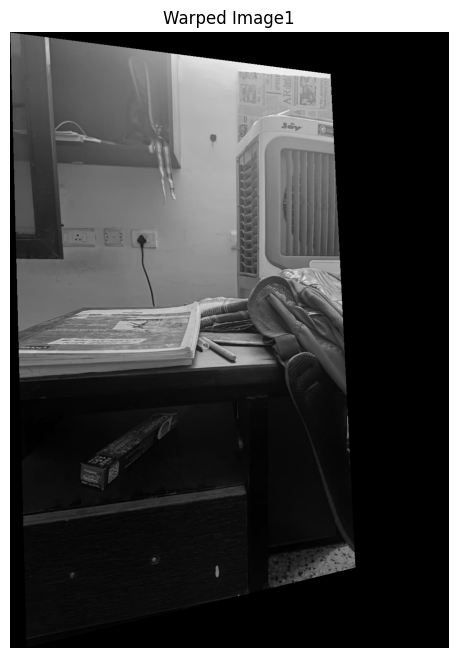

In [125]:
# =====================================================
# VISUALIZE WARPED IMAGE1
# =====================================================

plt.figure(figsize=(10,8))

plt.imshow(
    cv2.cvtColor(
        warped_img1,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title("Warped Image1")

plt.show()

In [126]:
# =====================================================
# CREATE VALID PIXEL MASKS
#
# Purpose:
# Identify which pixels belong
# to Image1 and Image2.
# =====================================================

mask1 = (
    np.any(
        warped_img1 > 0,
        axis=2
    )
).astype(np.float32)

mask2 = (
    np.any(
        img2_canvas > 0,
        axis=2
    )
).astype(np.float32)

print(mask1.shape)
print(mask2.shape)

(1486, 1057)
(1486, 1057)


In [127]:
# =====================================================
# DISTANCE TRANSFORM
#
# Purpose:
# Compute distance from image borders.
# Larger distance = stronger weight.
# =====================================================

from scipy.ndimage import distance_transform_edt

dist1 = (
    distance_transform_edt(mask1)
) ** 2

dist2 = (
    distance_transform_edt(mask2)
) ** 2

print(
    np.max(dist1),
    np.max(dist2)
)

151850.00000000003 409600.0


In [128]:
# =====================================================
# FEATHER WEIGHTS
#
# Purpose:
# Create blending weights.
# =====================================================

weight_sum = (
    dist1
    +
    dist2
    +
    1e-8
)

w1 = dist1 / weight_sum
w2 = dist2 / weight_sum

print(
    np.min(w1),
    np.max(w1)
)

print(
    np.min(w2),
    np.max(w2)
)

0.0 0.999999999999906
0.0 0.9999999999999756


In [129]:
# =====================================================
# FEATHER BLENDING
#
# Purpose:
# Create smooth panorama transition.
# =====================================================

panorama = np.zeros(
    warped_img1.shape,
    dtype=np.float32
)

for c in range(3):

    panorama[:,:,c] = (

        warped_img1[:,:,c]
        *
        w1

        +

        img2_canvas[:,:,c]
        *
        w2

    )

panorama = np.clip(
    panorama,
    0,
    255
).astype(np.uint8)

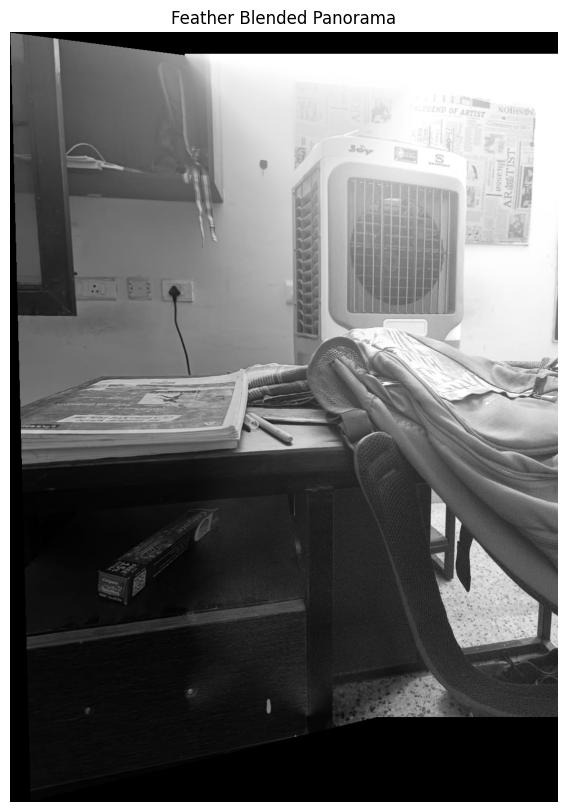

In [130]:
# =====================================================
# DISPLAY FINAL FEATHER BLENDED PANORAMA
# =====================================================

plt.figure(
    figsize=(12,10)
)

plt.imshow(
    cv2.cvtColor(
        panorama,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    "Feather Blended Panorama"
)

plt.show()

TILL NOW WE HAVE DONE:

✓ Gaussian Pyramid,
✓ DoG Pyramid,
✓ Keypoint Detection,
✓ Contrast Filtering,
✓ Edge Filtering,
✓ NMS,
✓ Orientation Assignment,
✓ Trilinear Descriptor,
✓ Descriptor Matching,
✓ Lowe Ratio Test,
✓ DLT Homography,
✓ Custom RANSAC,
✓ Homography Refinement,
✓ Symmetric Error,
✓ Inverse Warp,
✓ Panorama Canvas,
✓ Feather Blending,